## 0. Libraries & Setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, StratifiedKFold)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Libraries loaded successfully')

Libraries loaded successfully


---
## Part 1 – Data Preparation & Exploratory Data Analysis

### 5.1 Load Dataset

In [12]:
# Load the cleaned dataset directly
df = pd.read_csv('Data Cleaned.csv')

# Rename columns with special characters for easier handling
df.columns = df.columns.str.strip()
df.rename(columns={
    'body fat_%'             : 'body_fat_pct',
    'sit and bend forward_cm': 'sit_bend_cm',
    'sit-ups counts'         : 'situps_counts',
    'broad jump_cm'          : 'broad_jump_cm',
}, inplace=True)

print(f'Dataset Shape : {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Columns       : {list(df.columns)}')
print(f'\nMissing values: {df.isnull().sum().sum()}')
print(f'\nTarget (class) distribution:')
print(df['class'].value_counts().sort_index())
df.head()

Dataset Shape : 13288 rows x 13 columns
Columns       : ['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_pct', 'diastolic', 'systolic', 'gripForce', 'sit_bend_cm', 'situps_counts', 'broad_jump_cm', 'class', 'BMI']

Missing values: 0

Target (class) distribution:
class
0    3287
1    3337
2    3333
3    3331
Name: count, dtype: int64


,age,gender,height_cm,weight_kg,body_fat_pct,diastolic,systolic,gripForce,sit_bend_cm,situps_counts,broad_jump_cm,class,BMI
0,25,1,171.0,69.2,18.1,77.0,132,45.7,28.3,80,267.0,3,23.665401
1,34,1,169.9,74.7,15.1,83.0,138,50.1,19.0,78,250.0,2,25.878187
2,33,1,174.9,79.9,20.7,71.0,130,52.1,16.2,76,244.0,3,26.119638
3,32,1,173.0,74.7,12.0,84.0,122,53.8,23.0,76,274.0,3,24.959070
4,22,1,171.4,73.6,15.7,73.0,145,50.6,17.2,76,273.0,3,25.052795


---
## Part 2 – Decision Tree Model Training

### Feature & Target Preparation
> **Target:** `class` (0, 1, 2, 3) — already numeric, no encoding needed  
> **Gender:** already encoded as 0/1 in the dataset  
> **Regression target:** `broad_jump_cm` (continuous)

In [13]:
# All feature columns (excluding the target 'class')
FEATURES = ['age', 'gender', 'height_cm', 'weight_kg', 'body_fat_pct',
            'diastolic', 'systolic', 'gripForce', 'sit_bend_cm',
            'situps_counts', 'broad_jump_cm', 'BMI']

# Classification: predict 'class'
X_cls = df[FEATURES].copy()
y_cls = df['class'].copy()        # target: 0, 1, 2, 3 (already integers)

# Regression: predict 'broad_jump_cm' (remove it from features)
REG_FEATURES = [f for f in FEATURES if f != 'broad_jump_cm']
X_reg = df[REG_FEATURES].copy()
y_reg = df['broad_jump_cm'].copy()

# Class names for plotting
class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3']

print(f'Classification features : {len(FEATURES)}')
print(f'Classification target   : class {sorted(y_cls.unique())}')
print(f'Regression features     : {len(REG_FEATURES)}')
print(f'Regression target       : broad_jump_cm')
print(f'Total samples           : {len(df)}')

Classification features : 12
Classification target   : class [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Regression features     : 11
Regression target       : broad_jump_cm
Total samples           : 13288


### max_depth Tuning – Classification
> Test depths 1 to 20 to find the best depth that avoids overfitting/underfitting.

Best max_depth (Classification) = 9
Test Accuracy = 0.6719


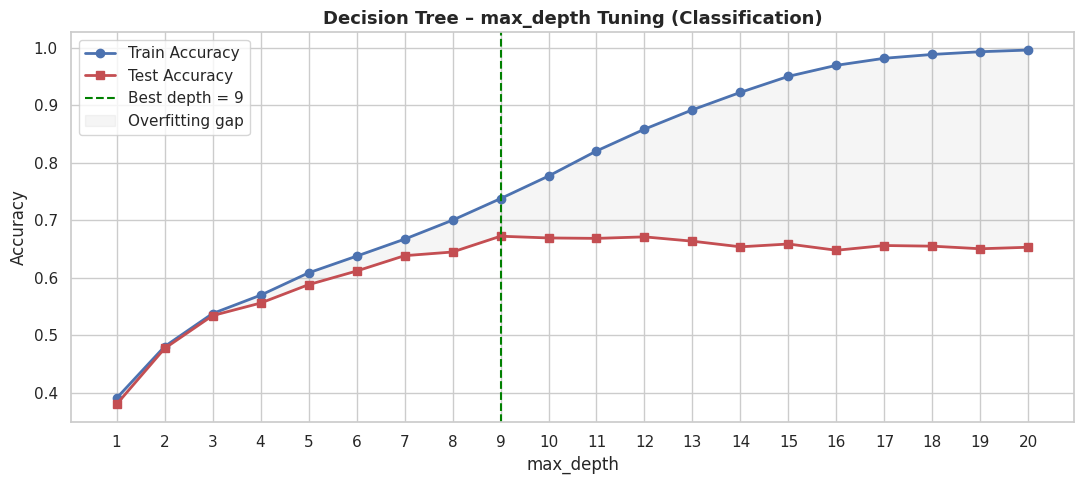

Saved: 06_depth_tuning_cls.png


In [14]:
depths = range(1, 21)
train_acc, test_acc = [], []

X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_tr, y_tr)
    train_acc.append(accuracy_score(y_tr, clf.predict(X_tr)))
    test_acc.append(accuracy_score(y_te, clf.predict(X_te)))

best_depth_cls = depths[np.argmax(test_acc)]
print(f'Best max_depth (Classification) = {best_depth_cls}')
print(f'Test Accuracy = {max(test_acc):.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, train_acc, 'o-', label='Train Accuracy', color='#4C72B0', linewidth=2)
ax.plot(depths, test_acc,  's-', label='Test Accuracy',  color='#C44E52', linewidth=2)
ax.axvline(best_depth_cls, color='green', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_depth_cls}')
ax.fill_between(depths, train_acc, test_acc, alpha=0.08, color='gray', label='Overfitting gap')
ax.set_xlabel('max_depth'); ax.set_ylabel('Accuracy')
ax.set_title('Decision Tree – max_depth Tuning (Classification)', fontsize=13, fontweight='bold')
ax.legend(); ax.set_xticks(list(depths))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_depth_tuning_cls.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_depth_tuning_cls.png')

### max_depth Tuning – Regression
> Predict `broad_jump_cm` as a continuous numerical target.

Best max_depth (Regression) = 7
Test R2 = 0.7550


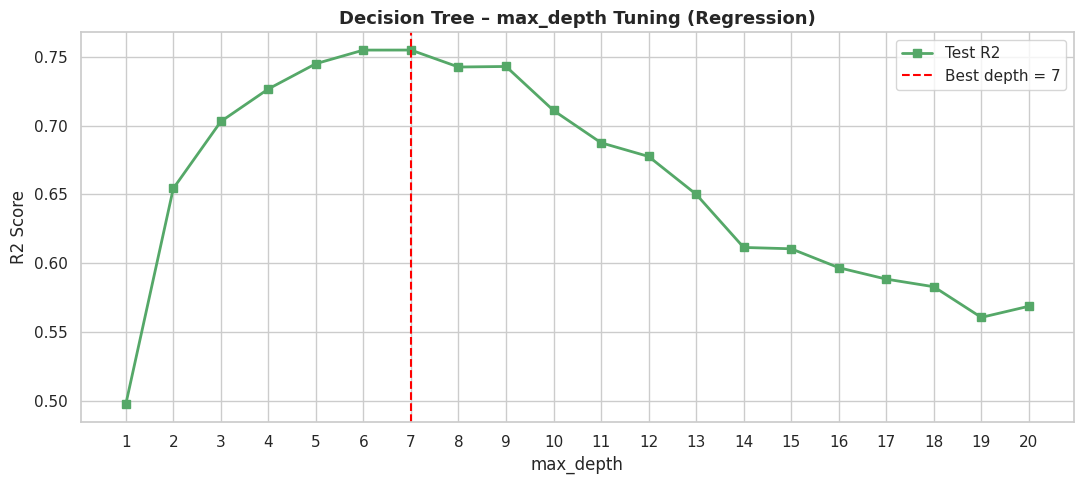

Saved: 07_depth_tuning_reg.png


In [15]:
r2_test_list = []
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

for d in depths:
    reg = DecisionTreeRegressor(max_depth=d, random_state=RANDOM_STATE)
    reg.fit(X_tr_r, y_tr_r)
    r2_test_list.append(r2_score(y_te_r, reg.predict(X_te_r)))

best_depth_reg = depths[np.argmax(r2_test_list)]
print(f'Best max_depth (Regression) = {best_depth_reg}')
print(f'Test R2 = {max(r2_test_list):.4f}')

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(depths, r2_test_list, 's-', color='#55A868', linewidth=2, label='Test R2')
ax.axvline(best_depth_reg, color='red', linestyle='--', linewidth=1.5,
           label=f'Best depth = {best_depth_reg}')
ax.set_xlabel('max_depth'); ax.set_ylabel('R2 Score')
ax.set_title('Decision Tree – max_depth Tuning (Regression)', fontsize=13, fontweight='bold')
ax.legend(); ax.set_xticks(list(depths))
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_depth_tuning_reg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_depth_tuning_reg.png')

### Cross-Validation Experiments
> Three train/test splits (80:20 · 70:30 · 50:50) + 10-Fold Cross Validation for both tasks.

In [16]:
splits = [(0.20, '80:20'), (0.30, '70:30'), (0.50, '50:50')]
cls_results = {}
reg_results = {}

for test_size, label in splits:
    # Classification
    Xtr, Xte, ytr, yte = train_test_split(
        X_cls, y_cls, test_size=test_size, random_state=RANDOM_STATE, stratify=y_cls)
    clf = DecisionTreeClassifier(max_depth=best_depth_cls, random_state=RANDOM_STATE)
    clf.fit(Xtr, ytr)
    ypred = clf.predict(Xte)
    cls_results[label] = {
        'Accuracy' : accuracy_score(yte, ypred),
        'Precision': precision_score(yte, ypred, average='weighted', zero_division=0),
        'Recall'   : recall_score(yte, ypred, average='weighted', zero_division=0),
        'F1'       : f1_score(yte, ypred, average='weighted', zero_division=0),
    }

    # Regression
    Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
        X_reg, y_reg, test_size=test_size, random_state=RANDOM_STATE)
    reg = DecisionTreeRegressor(max_depth=best_depth_reg, random_state=RANDOM_STATE)
    reg.fit(Xtr_r, ytr_r)
    ypred_r = reg.predict(Xte_r)
    mse = mean_squared_error(yte_r, ypred_r)
    reg_results[label] = {'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': r2_score(yte_r, ypred_r)}

# K-Fold CV
kf      = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
kfold_acc = cross_val_score(
    DecisionTreeClassifier(max_depth=best_depth_cls, random_state=RANDOM_STATE),
    X_cls, y_cls, cv=kf, scoring='accuracy')

kf_r    = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
kfold_r2 = cross_val_score(
    DecisionTreeRegressor(max_depth=best_depth_reg, random_state=RANDOM_STATE),
    X_reg, y_reg, cv=kf_r, scoring='r2')

# Print summary
print('=' * 60)
print('  Classification Results  (Target: class 0-3)')
print('=' * 60)
print(f"  {'Split':<8} {'Accuracy':>10} {'Precision':>10} {'Recall':>9} {'F1':>9}")
for label, m in cls_results.items():
    print(f"  {label:<8} {m['Accuracy']:>10.4f} {m['Precision']:>10.4f} "
          f"{m['Recall']:>9.4f} {m['F1']:>9.4f}")
print(f'\n  10-Fold CV: mean = {kfold_acc.mean():.4f}  std = {kfold_acc.std():.4f}')

print('\n' + '=' * 60)
print('  Regression Results  (Target: broad_jump_cm)')
print('=' * 60)
print(f"  {'Split':<8} {'MSE':>12} {'RMSE':>10} {'R2':>8}")
for label, m in reg_results.items():
    print(f"  {label:<8} {m['MSE']:>12.2f} {m['RMSE']:>10.4f} {m['R2']:>8.4f}")
print(f'\n  10-Fold CV: mean R2 = {kfold_r2.mean():.4f}  std = {kfold_r2.std():.4f}')

  Classification Results  (Target: class 0-3)
  Split      Accuracy  Precision    Recall        F1
  80:20        0.6719     0.6853    0.6719    0.6729
  70:30        0.6734     0.6809    0.6734    0.6747
  50:50        0.6600     0.6689    0.6600    0.6609

  10-Fold CV: mean = 0.6680  std = 0.0192

  Regression Results  (Target: broad_jump_cm)
  Split             MSE       RMSE       R2
  80:20          375.05    19.3661   0.7550
  70:30          367.65    19.1741   0.7662
  50:50          389.51    19.7361   0.7536

  10-Fold CV: mean R2 = 0.7531  std = 0.0118


---
## Part 3 – Performance Evaluation & Model Testing

### Classification Metrics – Accuracy · Precision · Recall · F1

In [17]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls)

clf_final = DecisionTreeClassifier(max_depth=best_depth_cls, random_state=RANDOM_STATE)
clf_final.fit(X_tr, y_tr)
y_pred_final = clf_final.predict(X_te)

print('Classification Report (80:20 split, best max_depth):')
print('=' * 55)
print(classification_report(y_te, y_pred_final,
                             target_names=class_names, zero_division=0))

Classification Report (80:20 split, best max_depth):
              precision    recall  f1-score   support

     Class 0       0.90      0.75      0.82       657
     Class 1       0.67      0.55      0.60       668
     Class 2       0.53      0.57      0.55       667
     Class 3       0.65      0.82      0.73       666

    accuracy                           0.67      2658
   macro avg       0.69      0.67      0.67      2658
weighted avg       0.69      0.67      0.67      2658



### Confusion Matrix

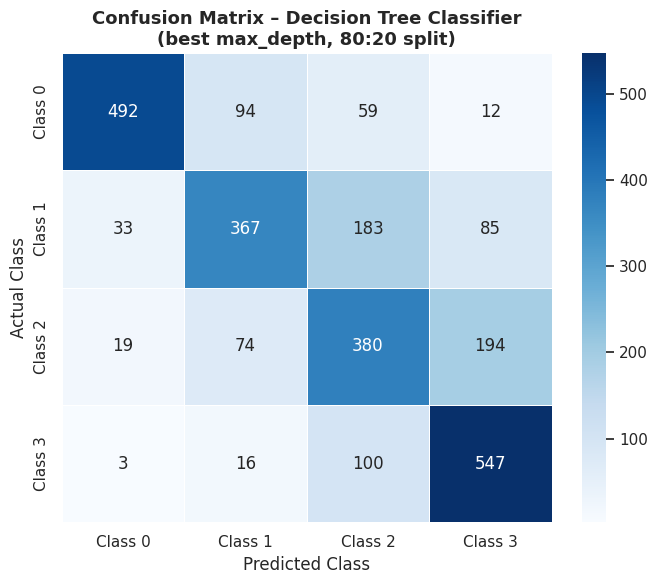

Saved: 08_confusion_matrix.png


In [18]:
cm = confusion_matrix(y_te, y_pred_final)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Class', fontsize=12)
ax.set_ylabel('Actual Class', fontsize=12)
ax.set_title('Confusion Matrix – Decision Tree Classifier\n(best max_depth, 80:20 split)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 08_confusion_matrix.png')

### Regression Metrics – MSE · RMSE · R²

In [19]:
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE)

reg_final = DecisionTreeRegressor(max_depth=best_depth_reg, random_state=RANDOM_STATE)
reg_final.fit(Xtr_r, ytr_r)
ypred_r_final = reg_final.predict(Xte_r)

mse_f  = mean_squared_error(yte_r, ypred_r_final)
rmse_f = np.sqrt(mse_f)
r2_f   = r2_score(yte_r, ypred_r_final)

metrics_df = pd.DataFrame({
    'Metric': ['MSE', 'RMSE', 'R2 Score'],
    'Value' : [round(mse_f, 4), round(rmse_f, 4), round(r2_f, 4)]
})
print('Regression Metrics – Predicting broad_jump_cm (80:20 split):')
print(metrics_df.to_string(index=False))

Regression Metrics – Predicting broad_jump_cm (80:20 split):
  Metric    Value
     MSE 375.0459
    RMSE  19.3661
R2 Score   0.7550


### Model Comparison Chart – All Splits & K-Fold

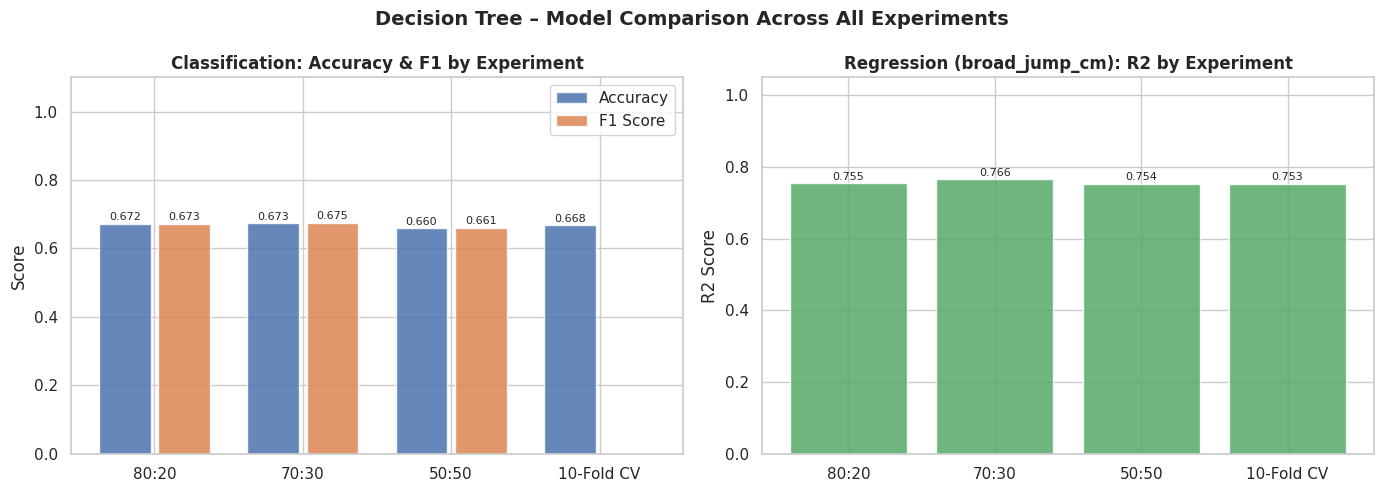

Saved: 09_model_comparison.png


In [20]:
split_labels = [s[1] for s in splits] + ['10-Fold CV']
acc_values   = [cls_results[l]['Accuracy'] for l in [s[1] for s in splits]] + [kfold_acc.mean()]
f1_values    = [cls_results[l]['F1']       for l in [s[1] for s in splits]] + [0]
r2_vals      = [reg_results[l]['R2']       for l in [s[1] for s in splits]] + [kfold_r2.mean()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(split_labels))

# Classification
bars1 = axes[0].bar(x - 0.2, acc_values, width=0.35, label='Accuracy', color='#4C72B0', alpha=0.85)
bars2 = axes[0].bar(x + 0.2, f1_values,  width=0.35, label='F1 Score', color='#DD8452', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(split_labels)
axes[0].set_ylim(0, 1.1); axes[0].set_ylabel('Score')
axes[0].set_title('Classification: Accuracy & F1 by Experiment', fontweight='bold')
axes[0].legend()
for bar in list(bars1) + list(bars2):
    if bar.get_height() > 0:
        axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                     f'{bar.get_height():.3f}', ha='center', fontsize=8)

# Regression
bars3 = axes[1].bar(split_labels, r2_vals, color='#55A868', alpha=0.85, edgecolor='white')
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel('R2 Score')
axes[1].set_title('Regression (broad_jump_cm): R2 by Experiment', fontweight='bold')
for bar in bars3:
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{bar.get_height():.3f}', ha='center', fontsize=8)

fig.suptitle('Decision Tree – Model Comparison Across All Experiments',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 09_model_comparison.png')

### Feature Importances

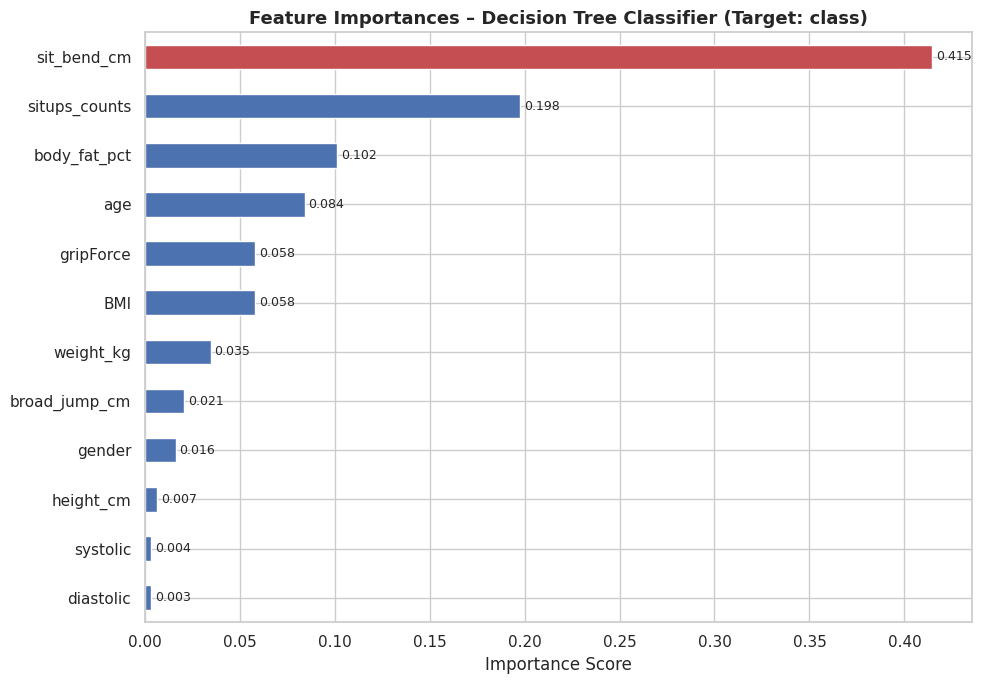

Most important feature: sit_bend_cm (0.415)
Saved: 10_feature_importance.png


In [21]:
importances = pd.Series(clf_final.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#C44E52' if imp == importances.max() else '#4C72B0' for imp in importances]
importances.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Feature Importances – Decision Tree Classifier (Target: class)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(importances):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Most important feature: {importances.idxmax()} ({importances.max():.3f})')
print('Saved: 10_feature_importance.png')

### Decision Tree Structure Visualisation
> Plotted at depth=4 for readability. Actual model uses the tuned depth.

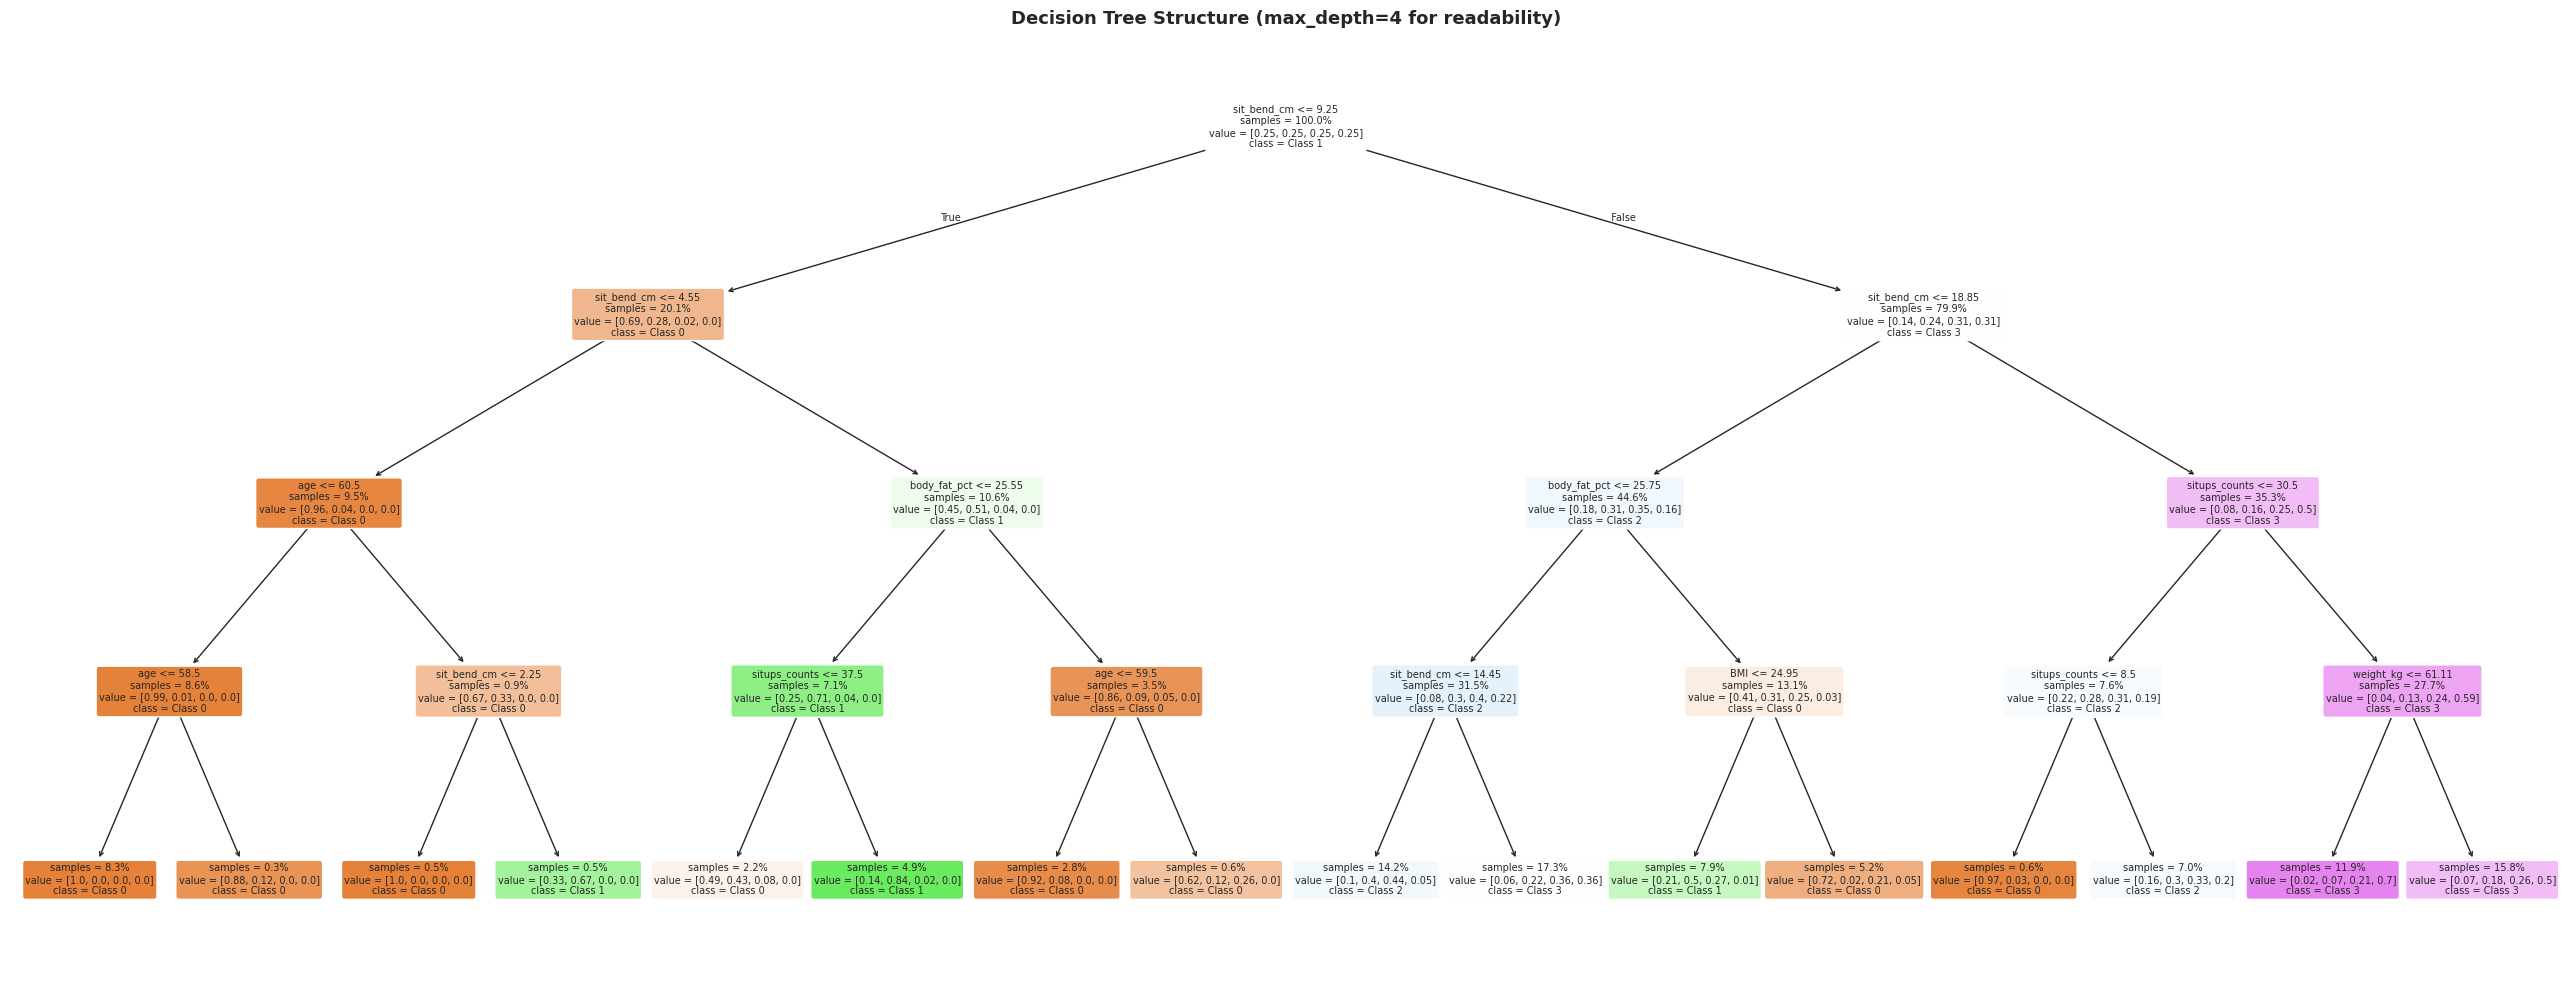

Saved: 11_decision_tree_structure.png


In [22]:
clf_vis = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
clf_vis.fit(X_tr, y_tr)

fig, ax = plt.subplots(figsize=(26, 10))
plot_tree(clf_vis, feature_names=FEATURES, class_names=class_names,
          filled=True, rounded=True, fontsize=7, ax=ax,
          impurity=False, proportion=True, precision=2)
ax.set_title('Decision Tree Structure (max_depth=4 for readability)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/11_decision_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 11_decision_tree_structure.png')

### K-Fold Cross Validation – Per-Fold Performance

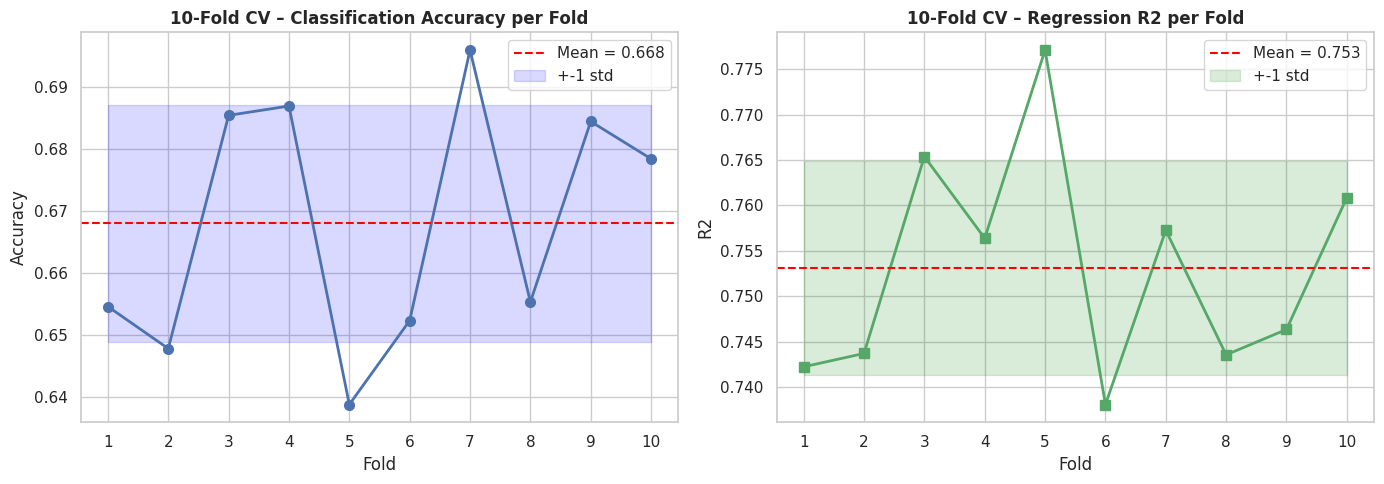

Saved: 12_kfold_per_fold.png


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
folds = range(1, 11)

axes[0].plot(folds, kfold_acc, 'o-', color='#4C72B0', linewidth=2, markersize=7)
axes[0].axhline(kfold_acc.mean(), linestyle='--', color='red', linewidth=1.5,
                label=f'Mean = {kfold_acc.mean():.3f}')
axes[0].fill_between(folds,
                     kfold_acc.mean() - kfold_acc.std(),
                     kfold_acc.mean() + kfold_acc.std(),
                     alpha=0.15, color='blue', label='+-1 std')
axes[0].set_xticks(list(folds)); axes[0].set_xlabel('Fold'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('10-Fold CV – Classification Accuracy per Fold', fontweight='bold')
axes[0].legend()

axes[1].plot(folds, kfold_r2, 's-', color='#55A868', linewidth=2, markersize=7)
axes[1].axhline(kfold_r2.mean(), linestyle='--', color='red', linewidth=1.5,
                label=f'Mean = {kfold_r2.mean():.3f}')
axes[1].fill_between(folds,
                     kfold_r2.mean() - kfold_r2.std(),
                     kfold_r2.mean() + kfold_r2.std(),
                     alpha=0.15, color='green', label='+-1 std')
axes[1].set_xticks(list(folds)); axes[1].set_xlabel('Fold'); axes[1].set_ylabel('R2')
axes[1].set_title('10-Fold CV – Regression R2 per Fold', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_kfold_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 12_kfold_per_fold.png')

---
## Final Summary

In [24]:
print('=' * 65)
print('  FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'  Dataset                         : Data_Cleaned.csv ({len(df)} rows)')
print(f'  Classification Target           : class (0, 1, 2, 3)')
print(f'  Regression Target               : broad_jump_cm')
print(f'  Features used                   : {len(FEATURES)} (including BMI)')
print(f'  Best max_depth (Classification) : {best_depth_cls}')
print(f'  Best max_depth (Regression)     : {best_depth_reg}')
print()
print('  CLASSIFICATION (80:20 split):')
print(f"    Accuracy  : {cls_results['80:20']['Accuracy']:.4f}")
print(f"    Precision : {cls_results['80:20']['Precision']:.4f}")
print(f"    Recall    : {cls_results['80:20']['Recall']:.4f}")
print(f"    F1 Score  : {cls_results['80:20']['F1']:.4f}")
print(f'    10-Fold CV: {kfold_acc.mean():.4f} +/- {kfold_acc.std():.4f}')
print()
print('  REGRESSION - broad_jump_cm (80:20 split):')
print(f'    MSE       : {mse_f:.4f}')
print(f'    RMSE      : {rmse_f:.4f}')
print(f'    R2 Score  : {r2_f:.4f}')
print(f'    10-Fold CV R2: {kfold_r2.mean():.4f} +/- {kfold_r2.std():.4f}')
print()
print('  Key Observations:')
print('  * class column used directly as target (already 0,1,2,3 integers).')
print('  * gender already encoded as 0/1 in dataset, no extra encoding needed.')
print('  * 80:20 split gives highest accuracy (more training data).')
print('  * 50:50 split reduces accuracy (fewer training samples).')
print('  * K-Fold CV provides the most stable performance estimate.')
print('  * gripForce and situps_counts are typically top classification features.')
print()
print('  All plots saved to:', OUTPUT_DIR)

  FINAL RESULTS SUMMARY
  Dataset                         : Data_Cleaned.csv (13288 rows)
  Classification Target           : class (0, 1, 2, 3)
  Regression Target               : broad_jump_cm
  Features used                   : 12 (including BMI)
  Best max_depth (Classification) : 9
  Best max_depth (Regression)     : 7

  CLASSIFICATION (80:20 split):
    Accuracy  : 0.6719
    Precision : 0.6853
    Recall    : 0.6719
    F1 Score  : 0.6729
    10-Fold CV: 0.6680 +/- 0.0192

  REGRESSION - broad_jump_cm (80:20 split):
    MSE       : 375.0459
    RMSE      : 19.3661
    R2 Score  : 0.7550
    10-Fold CV R2: 0.7531 +/- 0.0118

  Key Observations:
  * class column used directly as target (already 0,1,2,3 integers).
  * gender already encoded as 0/1 in dataset, no extra encoding needed.
  * 80:20 split gives highest accuracy (more training data).
  * 50:50 split reduces accuracy (fewer training samples).
  * K-Fold CV provides the most stable performance estimate.
  * gripForce and 